# FER Training Creation
Notebook for creating a training file matching api pulled data for FER 2013

In [1]:
import polars as pl
from pathlib import Path
import plotly.express as px

In [2]:
def bar_plot_counts(df, col):
    counts_df = df[col].value_counts().sort("count", descending=True)
    fig = px.bar(counts_df, x=col, y="count", title="Value Counts Bar Plot")
    fig.show()

In [3]:
fer_base = Path('../data/fer-2013')
data_source = 'fer2013'

In [4]:
def process_split(split_name):
    """Process one split (train or test)"""
    split_dir = fer_base / split_name
    
    if not split_dir.exists():
        print(f"Warning: {split_dir} does not exist")
        return None
    
    records = []
    for emotion_dir in split_dir.iterdir():
        if not emotion_dir.is_dir():
            continue
            
        emotion = emotion_dir.name
        
        for img_path in emotion_dir.glob('*.jpg'):
            records.append({
                'data_source': data_source,
                'face_path': '../data/' + str(img_path.relative_to(fer_base.parent)),
                'emotion': emotion
            })
    
    return pl.DataFrame(records)

In [5]:
# Process train
train_df = process_split('train')
if train_df is not None:
    print(f"Train: {len(train_df)} images")
    print(train_df['emotion'].value_counts().sort('emotion'))
    train_df.write_parquet(fer_base / 'fer2013_train.parquet')

Train: 28709 images
shape: (7, 2)
┌──────────┬───────┐
│ emotion  ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ angry    ┆ 3995  │
│ disgust  ┆ 436   │
│ fear     ┆ 4097  │
│ happy    ┆ 7215  │
│ neutral  ┆ 4965  │
│ sad      ┆ 4830  │
│ surprise ┆ 3171  │
└──────────┴───────┘


In [6]:
# Process test
test_df = process_split('test')
if test_df is not None:
    print(f"\nTest: {len(test_df)} images")
    print(test_df['emotion'].value_counts().sort('emotion'))
    test_df.write_parquet(fer_base / 'fer2013_test.parquet')


Test: 7178 images
shape: (7, 2)
┌──────────┬───────┐
│ emotion  ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ angry    ┆ 958   │
│ disgust  ┆ 111   │
│ fear     ┆ 1024  │
│ happy    ┆ 1774  │
│ neutral  ┆ 1233  │
│ sad      ┆ 1247  │
│ surprise ┆ 831   │
└──────────┴───────┘


In [7]:
# dropped unused emotions
drop_list = ['disgust', 'neutral']

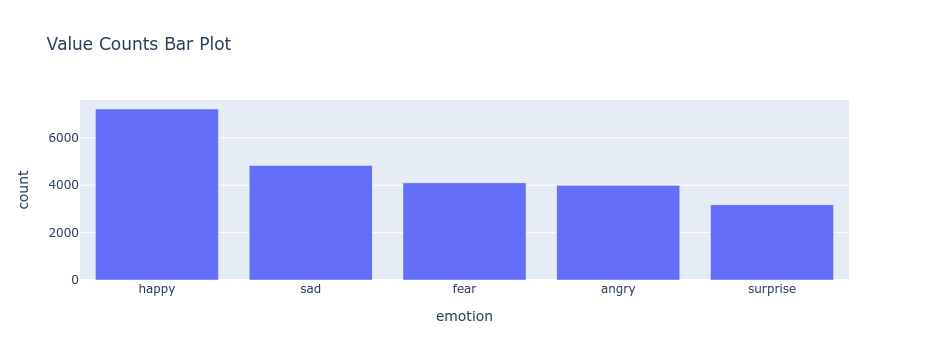

In [8]:
train_cut =  train_df.filter(~pl.col('emotion').is_in(drop_list))

bar_plot_counts(train_cut, 'emotion')

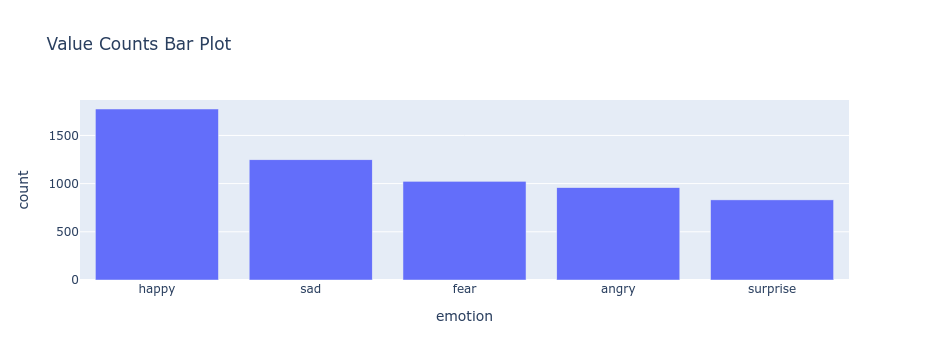

In [9]:
test_cut = test_df.filter(~pl.col('emotion').is_in(drop_list))

bar_plot_counts(test_cut, 'emotion')

In [10]:
train_cut.write_parquet(fer_base / 'fer2013_train_trimmed.parquet')
test_cut.write_parquet(fer_base / 'fer2013_test_trimmed.parquet')

In [11]:
train_df

data_source,face_path,emotion
str,str,str
"""fer2013""","""../data/fer-2013/train/sad/Tra…","""sad"""
"""fer2013""","""../data/fer-2013/train/sad/Tra…","""sad"""
"""fer2013""","""../data/fer-2013/train/sad/Tra…","""sad"""
"""fer2013""","""../data/fer-2013/train/sad/Tra…","""sad"""
"""fer2013""","""../data/fer-2013/train/sad/Tra…","""sad"""
…,…,…
"""fer2013""","""../data/fer-2013/train/angry/T…","""angry"""
"""fer2013""","""../data/fer-2013/train/angry/T…","""angry"""
"""fer2013""","""../data/fer-2013/train/angry/T…","""angry"""
